In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'VGG16'
MODEL_NAME

'VGG16'

In [8]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3

In [9]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for VGG16 transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics 
    norm_mean = [0.485, 0.456, 0.406]
    norm_std = [0.229, 0.224, 0.225]
    
    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [10]:
class VGG16(nn.Module):
    """
    VGG16-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: VGG16 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> None:
        super().__init__()

        # Load Pre-trained VGG16
        weights = models.VGG16_Weights.IMAGENET1K_V1
        backbone = models.vgg16(weights=weights)

        # VGG16 .features contains all Conv/Relu/MaxPool layers
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 512, H, W) -> (Batch, 512, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 512, 1, 1) -> (Batch, 512)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=512, out_features=num_classes) # VGG16 features output exactly 512 channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [11]:
def build_vgg16(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> VGG16:
    """
    Factory function to instantiate the customized VGG16 model for Transfer Learning.

    This function initializes a `VGG16` which includes:
    1. A frozen VGG16 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        VGG16Classifier: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = VGG16(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the VGG16 classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The current K-Fold index (used for naming the saved file).
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-3.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_vgg16().to(device=device)

    # Summary
    print(f"\nFold: {fold_k} - Block 6")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))
    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The index of the current fold (used for file naming and titles).
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_vgg16().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block 6)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def set_trainable_from_block(model: nn.Module, block_num: int) -> None:
    """
    Configures the trainability of VGG16 layers for fine-tuning.

    This function freezes all layers in the backbone (features) up to the specified
    `block_num`, and unfreezes all layers from that block onwards. 
    The custom classifier head is always set to be trainable.

    Mapping of VGG16 (torchvision) Feature Indices:
    - Block 5 starts at index 23
    - Block 4 starts at index 16
    - Block 3 starts at index 9
    - Block 2 starts at index 4
    - Block 1 starts at index 0

    Args:
        model (nn.Module): The VGG16 model instance.
        block_num (int): The block number (1 to 5) from which to start training.
            - 5: Train only the last convolutional block and classifier.
            - 1: Train the entire network.
    """

    # Map the abstract "Block Number" to the actual starting layer index in model.features
    block_indices = {
        5: 23,
        4: 16,
        3: 9,
        2: 4,
        1: 0,
    }

    start_index = block_indices[block_num]

    # 1. Configure Backbone (Feature Extractor)
    # Iterate through all layers in the 'features' sequential module
    for i, child in enumerate(model.features.children()):
        if i >= start_index:
            # Unfreeze: Allow gradient updates for layers in this block and above
            for param in child.parameters():
                param.requires_grad = True
        else:
            # Freeze: Prevent gradient updates for lower layers to preserve learned features
            for param in child.parameters():
                param.requires_grad = False

    # 2. Configure Classifier Head
    # The classification head (Dense layers) must always be trainable during fine-tuning
    for param in model.classifier.parameters():
        param.requires_grad = True

In [16]:
def train_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-5, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Fine-tunes a specific block of the VGG16 model (Progressive Fine-Tuning).

    Process:
    1. Identifies the checkpoint from the previous training stage (block + 1).
    2. Loads those weights into the model.
    3. Unfreezes layers starting from the current `block` downwards.
    4. Trains the model with a lower learning rate to adapt features without destroying them.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Fold index.
        block (int): The VGG block number to unfreeze (e.g., 5, 4, 3...).
        save_dir (str, optional): Directory for checkpoints. Defaults to SAVE_DIR.
        batch_size (int, optional): Batch size. Defaults to BATCH_SIZE.
        epochs (int, optional): Max epochs. Defaults to EPOCHS.
        learning_rate (float, optional): Learning rate (usually lower for fine-tuning). 
            Defaults to 1e-5.
        model_name (str, optional): Model naming prefix. Defaults to MODEL_NAME.

    Returns:
        dict[str, list[float]]: Training history dictionary.
    """

    # 1. Setup paths for previous and current checkpoints
    prev_block = block + 1
    prev_checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{prev_block}_fold_{fold_k}.pth')

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    # 2. Initialize Model & Load Previous Weights
    model = build_vgg16().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=prev_checkpoint_path, map_location=device, weights_only=True))
    
    # 3. Unfreeze specific layers
    # Use the helper function to set requires_grad=True for the target block
    set_trainable_from_block(model=model, block_num=block)

    # Summary
    print(f"\nFold: {fold_k} - Block {block}")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))
    
    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    
    criterion = SparseCategoricalFocalLoss()

    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    early_stop_patience = 6
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [17]:
def test_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the fine-tuning and evaluation pipeline for a specific VGG block.

    Process:
    1. Triggers `train_block` to fine-tune the model from the specified `block`.
    2. Loads the best weights saved during that fine-tuning session.
    3. Evaluates metrics (Loss/Accuracy).
    4. Generates Classification Report and Confusion Matrix.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Current Fold index.
        block (int): The specific block number being fine-tuned (e.g., 5, 4, 3).
        class_names (list[str], optional): Class labels for plotting. Defaults to CLASS_NAMES.
        save_dir (str, optional): Save directory. Defaults to SAVE_DIR.
        model_name (str, optional): Model prefix. Defaults to MODEL_NAME.

    Returns:
        float: Final validation accuracy.
    """

    # 1. Run Fine-Tuning for the specific block
    history = train_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block)

    # 2. Path to the best weights for THIS block
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    model = build_vgg16().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block {block})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Fold: 1 block 6
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 246MB/s]



Fold: 1 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass size (MB): 

Epoch 1/50 | loss: 0.4492 - accuracy: 0.5048 | val_loss: 0.4374 - val_accuracy: 0.4852
val_accuracy improved from 0.0000 to 0.4852, saving weights to /kaggle/working/VGG16_block_6_fold_1.pth


Epoch 2/50 | loss: 0.4125 - accuracy: 0.5702 | val_loss: 0.4017 - val_accuracy: 0.5701
val_accuracy improved from 0.4852 to 0.5701, saving weights to /kaggle/working/VGG16_block_6_fold_1.pth


...

Epoch 46/50 | loss: 0.1825 - accuracy: 0.8089 | val_loss: 0.1671 - val_accuracy: 0.8413
val_accuracy did not improve from 0.8469


Epoch 47/50 | loss: 0.1790 - accuracy: 0.8097 | val_loss: 0.1670 - val_accuracy: 0.8413
val_accuracy did not improve from 0.8469


Epoch 48/50 | loss: 0.1728 - accuracy: 0.8204 | val_loss: 0.1603 - val_accuracy: 0.8506
val_accuracy improved from 0.8469 to 0.8506, saving weights to /kaggle/working/VGG16_block_6_fold_1.pth


Epoch 49/50 | loss: 0.1747 - accuracy: 0.8176 | val_loss: 0.1644 - val_accuracy: 0.8395
val_accuracy did not improve from 0.8506


Epoch 50/50 | loss: 0.1800 - accuracy: 0.8113 | val_loss: 0.1570 - val_accuracy: 0.8579
val_accuracy improved from 0.8506 to 0.8579, saving weights to /kaggle/working/VGG16_block_6_fold_1.pth
   Model      Loss  Accuracy
0  VGG16  0.156978  0.857934
                  precision    recall  f1-score   support

    Glioma Tumor       0.83      0.98      0.90       245
Meningioma Tumor       0.75      0.70      0.72       112
 Pituitary Tumor       0.98      0.79      0.88       185

        accuracy                           0.86       542
       macro avg       0.85      0.82      0.83       542
    weighted avg       0.87      0.86      0.86       542



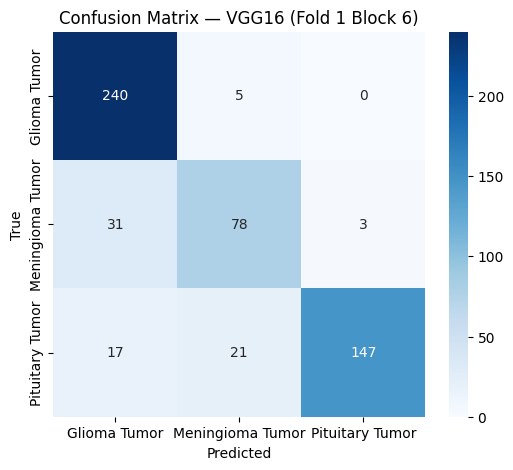

Fold: 1 block 5

Fold: 1 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.1578 - accuracy: 0.8255 | val_loss: 0.1276 - val_accuracy: 0.8598
val_accuracy improved from 0.0000 to 0.8598, saving weights to /kaggle/working/VGG16_block_5_fold_1.pth


Epoch 2/50 | loss: 0.1276 - accuracy: 0.8644 | val_loss: 0.1093 - val_accuracy: 0.8745
val_accuracy improved from 0.8598 to 0.8745, saving weights to /kaggle/working/VGG16_block_5_fold_1.pth


Epoch 3/50 | loss: 0.1176 - accuracy: 0.8644 | val_loss: 0.1126 - val_accuracy: 0.8856
val_accuracy improved from 0.8745 to 0.8856, saving weights to /kaggle/working/VGG16_block_5_fold_1.pth


Epoch 4/50 | loss: 0.1056 - accuracy: 0.8814 | val_loss: 0.0971 - val_accuracy: 0.8893
val_accuracy improved from 0.8856 to 0.8893, saving weights to /kaggle/working/VGG16_block_5_fold_1.pth


...

Epoch 19/50 | loss: 0.0450 - accuracy: 0.9477 | val_loss: 0.0602 - val_accuracy: 0.9077
val_accuracy did not improve from 0.9428


Epoch 20/50 | loss: 0.0419 - accuracy: 0.9453 | val_loss: 0.0543 - val_accuracy: 0.9354
val_accuracy did not improve from 0.9428


Epoch 21/50 | loss: 0.0412 - accuracy: 0.9492 | val_loss: 0.0509 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9428


Epoch 22/50 | loss: 0.0358 - accuracy: 0.9548 | val_loss: 0.0522 - val_accuracy: 0.9244
val_accuracy did not improve from 0.9428


Epoch 23/50 | loss: 0.0387 - accuracy: 0.9512 | val_loss: 0.0491 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9428
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.048825  0.942804
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.97      0.97       245
Meningioma Tumor       0.83      0.92      0.87       112
 Pituitary Tumor       0.99      0.92      0.96       185

        accuracy                           0.94       542
       macro avg       0.93      0.94      0.93       542
    weighted avg       0.95      0.94      0.94       542



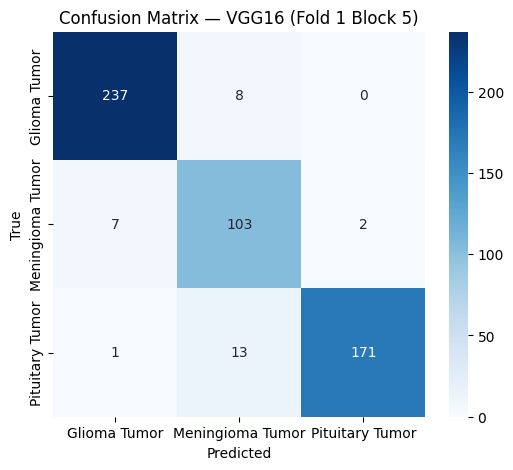

Fold: 1 block 4

Fold: 1 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0476 - accuracy: 0.9421 | val_loss: 0.0609 - val_accuracy: 0.9336
val_accuracy improved from 0.0000 to 0.9336, saving weights to /kaggle/working/VGG16_block_4_fold_1.pth


Epoch 2/50 | loss: 0.0394 - accuracy: 0.9524 | val_loss: 0.0494 - val_accuracy: 0.9354
val_accuracy improved from 0.9336 to 0.9354, saving weights to /kaggle/working/VGG16_block_4_fold_1.pth


Epoch 3/50 | loss: 0.0381 - accuracy: 0.9512 | val_loss: 0.0351 - val_accuracy: 0.9557
val_accuracy improved from 0.9354 to 0.9557, saving weights to /kaggle/working/VGG16_block_4_fold_1.pth


Epoch 4/50 | loss: 0.0335 - accuracy: 0.9627 | val_loss: 0.0660 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9557


Epoch 5/50 | loss: 0.0273 - accuracy: 0.9623 | val_loss: 0.0500 - val_accuracy: 0.9410
val_accuracy did not improve from 0.9557


Epoch 6/50 | loss: 0.0292 - accuracy: 0.9643 | val_loss: 0.0765 - val_accuracy: 0.9262
val_accuracy did not improve from 0.9557


Epoch 7/50 | loss: 0.0269 - accuracy: 0.9643 | val_loss: 0.0567 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9557


Epoch 8/50 | loss: 0.0200 - accuracy: 0.9746 | val_loss: 0.0533 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9557


Epoch 9/50 | loss: 0.0247 - accuracy: 0.9695 | val_loss: 0.0481 - val_accuracy: 0.9465
val_accuracy did not improve from 0.9557
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.035117   0.95572
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.98      0.97       245
Meningioma Tumor       0.89      0.90      0.90       112
 Pituitary Tumor       0.97      0.96      0.97       185

        accuracy                           0.96       542
       macro avg       0.95      0.95      0.95       542
    weighted avg       0.96      0.96      0.96       542



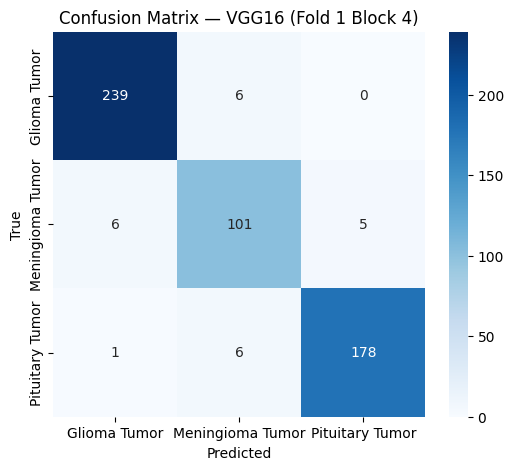

Fold: 1 block 3

Fold: 1 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0378 - accuracy: 0.9552 | val_loss: 0.0427 - val_accuracy: 0.9428
val_accuracy improved from 0.0000 to 0.9428, saving weights to /kaggle/working/VGG16_block_3_fold_1.pth


Epoch 2/50 | loss: 0.0310 - accuracy: 0.9611 | val_loss: 0.0475 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9428


Epoch 3/50 | loss: 0.0316 - accuracy: 0.9631 | val_loss: 0.0572 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9428


Epoch 4/50 | loss: 0.0279 - accuracy: 0.9627 | val_loss: 0.0368 - val_accuracy: 0.9483
val_accuracy improved from 0.9428 to 0.9483, saving weights to /kaggle/working/VGG16_block_3_fold_1.pth


...

Epoch 14/50 | loss: 0.0095 - accuracy: 0.9889 | val_loss: 0.0450 - val_accuracy: 0.9520
val_accuracy did not improve from 0.9557


Epoch 15/50 | loss: 0.0089 - accuracy: 0.9873 | val_loss: 0.0506 - val_accuracy: 0.9502
val_accuracy did not improve from 0.9557


Epoch 16/50 | loss: 0.0090 - accuracy: 0.9881 | val_loss: 0.0431 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9557


Epoch 17/50 | loss: 0.0106 - accuracy: 0.9881 | val_loss: 0.0438 - val_accuracy: 0.9539
val_accuracy did not improve from 0.9557


Epoch 18/50 | loss: 0.0096 - accuracy: 0.9873 | val_loss: 0.0418 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9557
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.040718   0.95572
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.97      0.98       245
Meningioma Tumor       0.85      0.95      0.90       112
 Pituitary Tumor       0.99      0.94      0.97       185

        accuracy                           0.96       542
       macro avg       0.94      0.95      0.95       542
    weighted avg       0.96      0.96      0.96       542



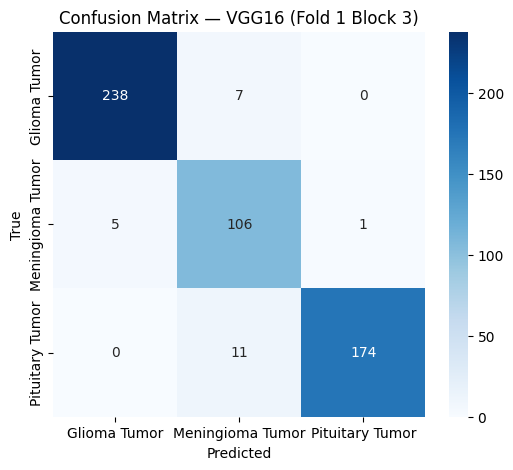

Fold: 1 block 2

Fold: 1 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0154 - accuracy: 0.9806 | val_loss: 0.0347 - val_accuracy: 0.9613
val_accuracy improved from 0.0000 to 0.9613, saving weights to /kaggle/working/VGG16_block_2_fold_1.pth


Epoch 2/50 | loss: 0.0110 - accuracy: 0.9833 | val_loss: 0.0595 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9613


Epoch 3/50 | loss: 0.0158 - accuracy: 0.9806 | val_loss: 0.0342 - val_accuracy: 0.9576
val_accuracy did not improve from 0.9613


Epoch 4/50 | loss: 0.0104 - accuracy: 0.9865 | val_loss: 0.0342 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9613


...

Epoch 9/50 | loss: 0.0089 - accuracy: 0.9877 | val_loss: 0.0564 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9631


Epoch 10/50 | loss: 0.0095 - accuracy: 0.9905 | val_loss: 0.0278 - val_accuracy: 0.9576
val_accuracy did not improve from 0.9631


Epoch 11/50 | loss: 0.0122 - accuracy: 0.9877 | val_loss: 0.0460 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9631


Epoch 12/50 | loss: 0.0064 - accuracy: 0.9893 | val_loss: 0.0375 - val_accuracy: 0.9631
val_accuracy did not improve from 0.9631


Epoch 13/50 | loss: 0.0085 - accuracy: 0.9897 | val_loss: 0.0346 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9631
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.029717    0.9631
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.96      0.97       245
Meningioma Tumor       0.87      0.96      0.92       112
 Pituitary Tumor       0.99      0.97      0.98       185

        accuracy                           0.96       542
       macro avg       0.95      0.96      0.96       542
    weighted avg       0.97      0.96      0.96       542



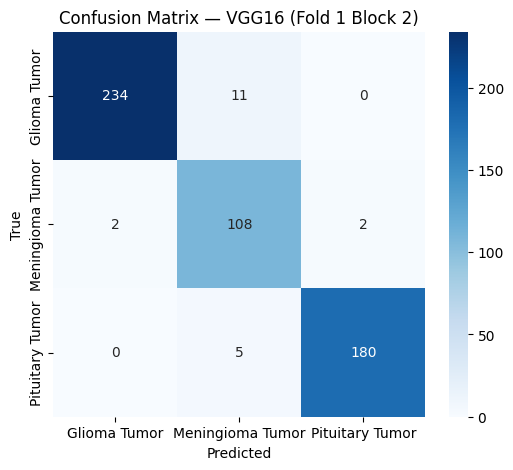

Fold: 1 block 1

Fold: 1 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0100 - accuracy: 0.9869 | val_loss: 0.0536 - val_accuracy: 0.9483
val_accuracy improved from 0.0000 to 0.9483, saving weights to /kaggle/working/VGG16_block_1_fold_1.pth


Epoch 2/50 | loss: 0.0087 - accuracy: 0.9897 | val_loss: 0.0356 - val_accuracy: 0.9557
val_accuracy improved from 0.9483 to 0.9557, saving weights to /kaggle/working/VGG16_block_1_fold_1.pth


Epoch 3/50 | loss: 0.0098 - accuracy: 0.9877 | val_loss: 0.0367 - val_accuracy: 0.9649
val_accuracy improved from 0.9557 to 0.9649, saving weights to /kaggle/working/VGG16_block_1_fold_1.pth


Epoch 4/50 | loss: 0.0051 - accuracy: 0.9944 | val_loss: 0.0363 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9649


...

Epoch 11/50 | loss: 0.0043 - accuracy: 0.9956 | val_loss: 0.0372 - val_accuracy: 0.9668
val_accuracy did not improve from 0.9705


Epoch 12/50 | loss: 0.0109 - accuracy: 0.9905 | val_loss: 0.0281 - val_accuracy: 0.9668
val_accuracy did not improve from 0.9705


Epoch 13/50 | loss: 0.0079 - accuracy: 0.9905 | val_loss: 0.0470 - val_accuracy: 0.9520
val_accuracy did not improve from 0.9705


Epoch 14/50 | loss: 0.0067 - accuracy: 0.9913 | val_loss: 0.0347 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9705


Epoch 15/50 | loss: 0.0047 - accuracy: 0.9948 | val_loss: 0.0449 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9705
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.032589   0.97048
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.99      0.98       245
Meningioma Tumor       0.91      0.95      0.93       112
 Pituitary Tumor       1.00      0.96      0.98       185

        accuracy                           0.97       542
       macro avg       0.96      0.97      0.96       542
    weighted avg       0.97      0.97      0.97       542



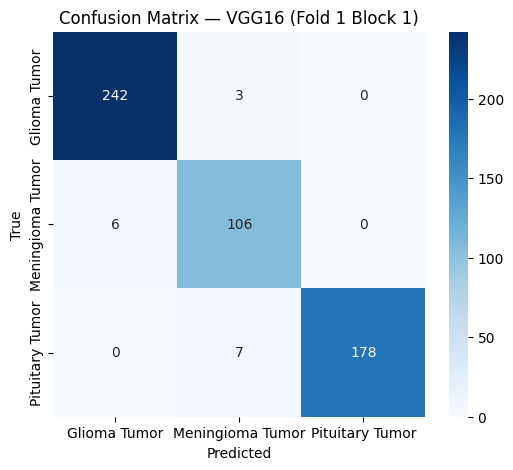

Fold: 2 block 6

Fold: 2 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.4698 - accuracy: 0.4465 | val_loss: 0.4557 - val_accuracy: 0.4978
val_accuracy improved from 0.0000 to 0.4978, saving weights to /kaggle/working/VGG16_block_6_fold_2.pth


Epoch 2/50 | loss: 0.4310 - accuracy: 0.5363 | val_loss: 0.4172 - val_accuracy: 0.5567
val_accuracy improved from 0.4978 to 0.5567, saving weights to /kaggle/working/VGG16_block_6_fold_2.pth


Epoch 3/50 | loss: 0.3993 - accuracy: 0.6184 | val_loss: 0.3877 - val_accuracy: 0.6171
val_accuracy improved from 0.5567 to 0.6171, saving weights to /kaggle/working/VGG16_block_6_fold_2.pth


Epoch 4/50 | loss: 0.3683 - accuracy: 0.6633 | val_loss: 0.3624 - val_accuracy: 0.6554
val_accuracy improved from 0.6171 to 0.6554, saving weights to /kaggle/working/VGG16_block_6_fold_2.pth


...

Epoch 39/50 | loss: 0.1869 - accuracy: 0.8075 | val_loss: 0.1775 - val_accuracy: 0.7982
val_accuracy did not improve from 0.8027


Epoch 40/50 | loss: 0.1820 - accuracy: 0.8122 | val_loss: 0.1772 - val_accuracy: 0.7953
val_accuracy did not improve from 0.8027


Epoch 41/50 | loss: 0.1794 - accuracy: 0.8218 | val_loss: 0.1777 - val_accuracy: 0.7938
val_accuracy did not improve from 0.8027


Epoch 42/50 | loss: 0.1818 - accuracy: 0.8147 | val_loss: 0.1761 - val_accuracy: 0.7968
val_accuracy did not improve from 0.8027


Epoch 43/50 | loss: 0.1792 - accuracy: 0.8214 | val_loss: 0.1764 - val_accuracy: 0.7982
val_accuracy did not improve from 0.8027
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.179687  0.802651
                  precision    recall  f1-score   support

    Glioma Tumor       0.77      0.92      0.84       338
Meningioma Tumor       0.73      0.53      0.61       167
 Pituitary Tumor       0.96      0.83      0.89       174

        accuracy                           0.80       679
       macro avg       0.82      0.76      0.78       679
    weighted avg       0.81      0.80      0.80       679



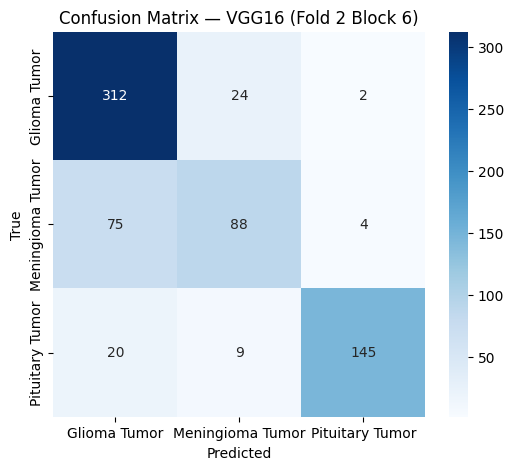

Fold: 2 block 5

Fold: 2 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.1606 - accuracy: 0.8319 | val_loss: 0.1509 - val_accuracy: 0.8056
val_accuracy improved from 0.0000 to 0.8056, saving weights to /kaggle/working/VGG16_block_5_fold_2.pth


Epoch 2/50 | loss: 0.1294 - accuracy: 0.8512 | val_loss: 0.1223 - val_accuracy: 0.8336
val_accuracy improved from 0.8056 to 0.8336, saving weights to /kaggle/working/VGG16_block_5_fold_2.pth


Epoch 3/50 | loss: 0.1108 - accuracy: 0.8864 | val_loss: 0.1373 - val_accuracy: 0.8292
val_accuracy did not improve from 0.8336


Epoch 4/50 | loss: 0.1031 - accuracy: 0.8830 | val_loss: 0.1166 - val_accuracy: 0.8409
val_accuracy improved from 0.8336 to 0.8409, saving weights to /kaggle/working/VGG16_block_5_fold_2.pth


...

Epoch 17/50 | loss: 0.0445 - accuracy: 0.9455 | val_loss: 0.0905 - val_accuracy: 0.8851
val_accuracy did not improve from 0.8984


Epoch 18/50 | loss: 0.0446 - accuracy: 0.9421 | val_loss: 0.0849 - val_accuracy: 0.8925
val_accuracy did not improve from 0.8984


Epoch 19/50 | loss: 0.0466 - accuracy: 0.9405 | val_loss: 0.0847 - val_accuracy: 0.8910
val_accuracy did not improve from 0.8984


Epoch 20/50 | loss: 0.0476 - accuracy: 0.9384 | val_loss: 0.0848 - val_accuracy: 0.8910
val_accuracy did not improve from 0.8984


Epoch 21/50 | loss: 0.0496 - accuracy: 0.9375 | val_loss: 0.0871 - val_accuracy: 0.8866
val_accuracy did not improve from 0.8984
early stopping, restoring model weights from the end of the best epoch
   Model     Loss  Accuracy
0  VGG16  0.08175   0.89838
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.91      0.92       338
Meningioma Tumor       0.79      0.89      0.83       167
 Pituitary Tumor       0.97      0.88      0.92       174

        accuracy                           0.90       679
       macro avg       0.90      0.89      0.89       679
    weighted avg       0.90      0.90      0.90       679



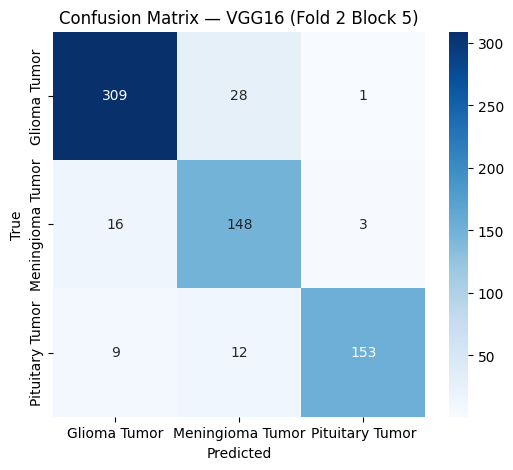

Fold: 2 block 4

Fold: 2 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0528 - accuracy: 0.9392 | val_loss: 0.0801 - val_accuracy: 0.9057
val_accuracy improved from 0.0000 to 0.9057, saving weights to /kaggle/working/VGG16_block_4_fold_2.pth


Epoch 2/50 | loss: 0.0469 - accuracy: 0.9392 | val_loss: 0.1218 - val_accuracy: 0.8719
val_accuracy did not improve from 0.9057


Epoch 3/50 | loss: 0.0434 - accuracy: 0.9497 | val_loss: 0.0993 - val_accuracy: 0.8881
val_accuracy did not improve from 0.9057


Epoch 4/50 | loss: 0.0410 - accuracy: 0.9488 | val_loss: 0.0780 - val_accuracy: 0.9116
val_accuracy improved from 0.9057 to 0.9116, saving weights to /kaggle/working/VGG16_block_4_fold_2.pth


...

Epoch 14/50 | loss: 0.0155 - accuracy: 0.9820 | val_loss: 0.0897 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9219


Epoch 15/50 | loss: 0.0171 - accuracy: 0.9845 | val_loss: 0.0803 - val_accuracy: 0.9161
val_accuracy did not improve from 0.9219


Epoch 16/50 | loss: 0.0157 - accuracy: 0.9778 | val_loss: 0.0796 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9219


Epoch 17/50 | loss: 0.0146 - accuracy: 0.9866 | val_loss: 0.0781 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9219


Epoch 18/50 | loss: 0.0138 - accuracy: 0.9811 | val_loss: 0.0788 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9219
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.077347  0.921944
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.95      0.93       338
Meningioma Tumor       0.88      0.88      0.88       167
 Pituitary Tumor       0.98      0.91      0.94       174

        accuracy                           0.92       679
       macro avg       0.92      0.91      0.92       679
    weighted avg       0.92      0.92      0.92       679



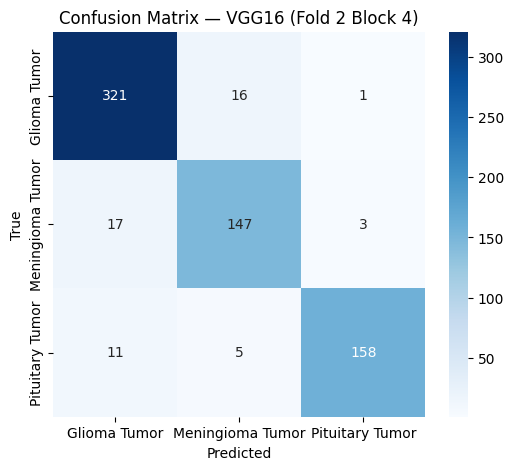

Fold: 2 block 3

Fold: 2 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0224 - accuracy: 0.9698 | val_loss: 0.0995 - val_accuracy: 0.9102
val_accuracy improved from 0.0000 to 0.9102, saving weights to /kaggle/working/VGG16_block_3_fold_2.pth


Epoch 2/50 | loss: 0.0217 - accuracy: 0.9727 | val_loss: 0.0723 - val_accuracy: 0.9175
val_accuracy improved from 0.9102 to 0.9175, saving weights to /kaggle/working/VGG16_block_3_fold_2.pth


Epoch 3/50 | loss: 0.0154 - accuracy: 0.9811 | val_loss: 0.0780 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9175


Epoch 4/50 | loss: 0.0221 - accuracy: 0.9694 | val_loss: 0.0736 - val_accuracy: 0.9205
val_accuracy improved from 0.9175 to 0.9205, saving weights to /kaggle/working/VGG16_block_3_fold_2.pth


...

Epoch 15/50 | loss: 0.0080 - accuracy: 0.9899 | val_loss: 0.0994 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9234


Epoch 16/50 | loss: 0.0067 - accuracy: 0.9925 | val_loss: 0.1006 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9234


Epoch 17/50 | loss: 0.0067 - accuracy: 0.9916 | val_loss: 0.1020 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9234


Epoch 18/50 | loss: 0.0071 - accuracy: 0.9916 | val_loss: 0.1021 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9234


Epoch 19/50 | loss: 0.0056 - accuracy: 0.9933 | val_loss: 0.1006 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9234
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.096013  0.923417
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.93      0.93       338
Meningioma Tumor       0.85      0.90      0.88       167
 Pituitary Tumor       0.98      0.92      0.95       174

        accuracy                           0.92       679
       macro avg       0.92      0.92      0.92       679
    weighted avg       0.93      0.92      0.92       679



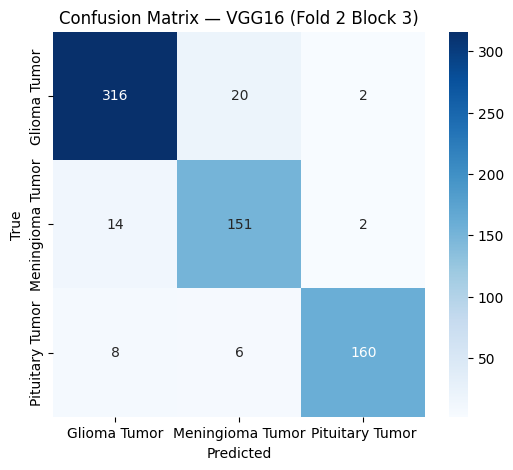

Fold: 2 block 2

Fold: 2 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0154 - accuracy: 0.9816 | val_loss: 0.1300 - val_accuracy: 0.9116
val_accuracy improved from 0.0000 to 0.9116, saving weights to /kaggle/working/VGG16_block_2_fold_2.pth


Epoch 2/50 | loss: 0.0134 - accuracy: 0.9807 | val_loss: 0.0960 - val_accuracy: 0.9190
val_accuracy improved from 0.9116 to 0.9190, saving weights to /kaggle/working/VGG16_block_2_fold_2.pth


Epoch 3/50 | loss: 0.0078 - accuracy: 0.9908 | val_loss: 0.1629 - val_accuracy: 0.8940
val_accuracy did not improve from 0.9190


Epoch 4/50 | loss: 0.0135 - accuracy: 0.9824 | val_loss: 0.1029 - val_accuracy: 0.9205
val_accuracy improved from 0.9190 to 0.9205, saving weights to /kaggle/working/VGG16_block_2_fold_2.pth


...

Epoch 6/50 | loss: 0.0077 - accuracy: 0.9912 | val_loss: 0.1335 - val_accuracy: 0.9087
val_accuracy did not improve from 0.9205


Epoch 7/50 | loss: 0.0055 - accuracy: 0.9925 | val_loss: 0.1126 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9205


Epoch 8/50 | loss: 0.0047 - accuracy: 0.9933 | val_loss: 0.1122 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9205


Epoch 9/50 | loss: 0.0047 - accuracy: 0.9929 | val_loss: 0.1032 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9205


Epoch 10/50 | loss: 0.0041 - accuracy: 0.9962 | val_loss: 0.1034 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9205
early stopping, restoring model weights from the end of the best epoch
   Model     Loss  Accuracy
0  VGG16  0.10287  0.920471
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.96      0.94       338
Meningioma Tumor       0.91      0.81      0.86       167
 Pituitary Tumor       0.95      0.95      0.95       174

        accuracy                           0.92       679
       macro avg       0.92      0.91      0.91       679
    weighted avg       0.92      0.92      0.92       679



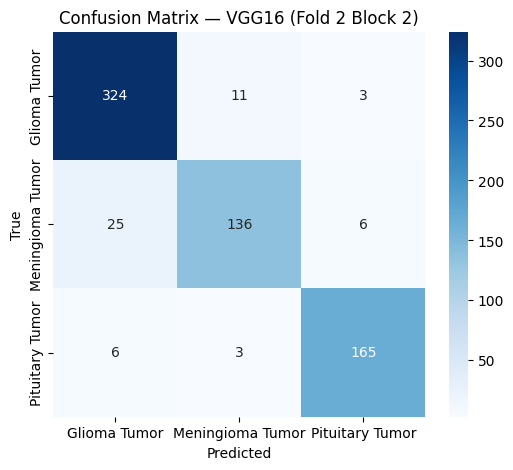

Fold: 2 block 1

Fold: 2 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0106 - accuracy: 0.9887 | val_loss: 0.0768 - val_accuracy: 0.9278
val_accuracy improved from 0.0000 to 0.9278, saving weights to /kaggle/working/VGG16_block_1_fold_2.pth


Epoch 2/50 | loss: 0.0094 - accuracy: 0.9895 | val_loss: 0.1045 - val_accuracy: 0.9234
val_accuracy did not improve from 0.9278


Epoch 3/50 | loss: 0.0074 - accuracy: 0.9895 | val_loss: 0.0905 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9278


Epoch 4/50 | loss: 0.0078 - accuracy: 0.9912 | val_loss: 0.1361 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9278


Epoch 5/50 | loss: 0.0146 - accuracy: 0.9795 | val_loss: 0.1244 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9278


Epoch 6/50 | loss: 0.0054 - accuracy: 0.9971 | val_loss: 0.0986 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9278


Epoch 7/50 | loss: 0.0036 - accuracy: 0.9966 | val_loss: 0.1013 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9278
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.076781  0.927835
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.93      0.94       338
Meningioma Tumor       0.85      0.91      0.88       167
 Pituitary Tumor       0.96      0.94      0.95       174

        accuracy                           0.93       679
       macro avg       0.92      0.93      0.92       679
    weighted avg       0.93      0.93      0.93       679



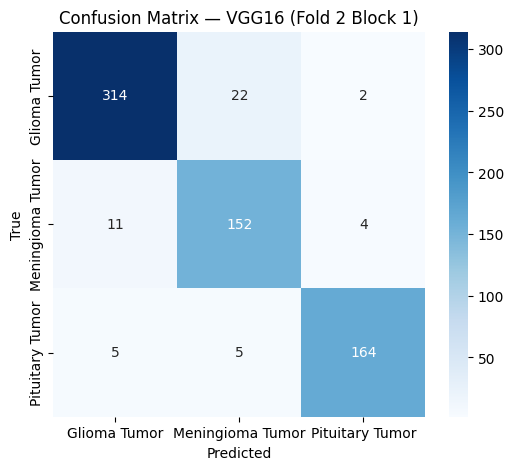

Fold: 3 block 6

Fold: 3 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.4532 - accuracy: 0.5060 | val_loss: 0.4407 - val_accuracy: 0.4615
val_accuracy improved from 0.0000 to 0.4615, saving weights to /kaggle/working/VGG16_block_6_fold_3.pth


Epoch 2/50 | loss: 0.4198 - accuracy: 0.5618 | val_loss: 0.4098 - val_accuracy: 0.5105
val_accuracy improved from 0.4615 to 0.5105, saving weights to /kaggle/working/VGG16_block_6_fold_3.pth


Epoch 3/50 | loss: 0.3872 - accuracy: 0.6240 | val_loss: 0.3803 - val_accuracy: 0.5769
val_accuracy improved from 0.5105 to 0.5769, saving weights to /kaggle/working/VGG16_block_6_fold_3.pth


Epoch 4/50 | loss: 0.3648 - accuracy: 0.6561 | val_loss: 0.3622 - val_accuracy: 0.5822
val_accuracy improved from 0.5769 to 0.5822, saving weights to /kaggle/working/VGG16_block_6_fold_3.pth


...

Epoch 35/50 | loss: 0.1919 - accuracy: 0.8110 | val_loss: 0.1732 - val_accuracy: 0.8269
val_accuracy did not improve from 0.8322


Epoch 36/50 | loss: 0.1909 - accuracy: 0.8090 | val_loss: 0.1725 - val_accuracy: 0.8269
val_accuracy did not improve from 0.8322


Epoch 37/50 | loss: 0.1840 - accuracy: 0.8254 | val_loss: 0.1694 - val_accuracy: 0.8304
val_accuracy did not improve from 0.8322


Epoch 38/50 | loss: 0.1853 - accuracy: 0.8090 | val_loss: 0.1710 - val_accuracy: 0.8287
val_accuracy did not improve from 0.8322


Epoch 39/50 | loss: 0.1846 - accuracy: 0.8090 | val_loss: 0.1684 - val_accuracy: 0.8304
val_accuracy did not improve from 0.8322
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.176979  0.832168
                  precision    recall  f1-score   support

    Glioma Tumor       0.75      0.92      0.82       231
Meningioma Tumor       0.78      0.55      0.65       139
 Pituitary Tumor       0.98      0.93      0.95       202

        accuracy                           0.83       572
       macro avg       0.84      0.80      0.81       572
    weighted avg       0.84      0.83      0.83       572



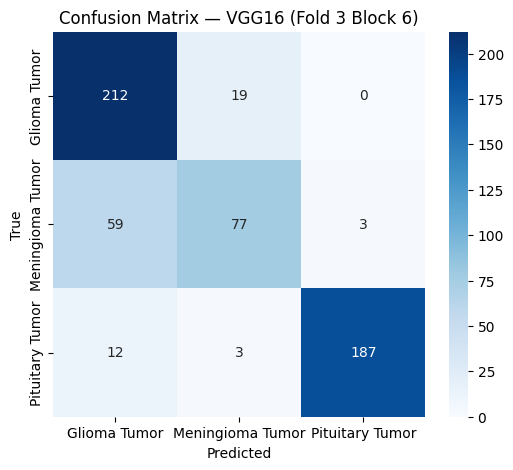

Fold: 3 block 5

Fold: 3 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.1629 - accuracy: 0.8295 | val_loss: 0.1237 - val_accuracy: 0.8566
val_accuracy improved from 0.0000 to 0.8566, saving weights to /kaggle/working/VGG16_block_5_fold_3.pth


Epoch 2/50 | loss: 0.1330 - accuracy: 0.8559 | val_loss: 0.1052 - val_accuracy: 0.8794
val_accuracy improved from 0.8566 to 0.8794, saving weights to /kaggle/working/VGG16_block_5_fold_3.pth


Epoch 3/50 | loss: 0.1162 - accuracy: 0.8688 | val_loss: 0.1059 - val_accuracy: 0.8881
val_accuracy improved from 0.8794 to 0.8881, saving weights to /kaggle/working/VGG16_block_5_fold_3.pth


Epoch 4/50 | loss: 0.1029 - accuracy: 0.8792 | val_loss: 0.0969 - val_accuracy: 0.8899
val_accuracy improved from 0.8881 to 0.8899, saving weights to /kaggle/working/VGG16_block_5_fold_3.pth


...

Epoch 18/50 | loss: 0.0467 - accuracy: 0.9446 | val_loss: 0.0735 - val_accuracy: 0.9021
val_accuracy did not improve from 0.9091


Epoch 19/50 | loss: 0.0458 - accuracy: 0.9414 | val_loss: 0.0739 - val_accuracy: 0.9073
val_accuracy did not improve from 0.9091


Epoch 20/50 | loss: 0.0435 - accuracy: 0.9474 | val_loss: 0.0828 - val_accuracy: 0.8986
val_accuracy did not improve from 0.9091


Epoch 21/50 | loss: 0.0380 - accuracy: 0.9571 | val_loss: 0.0756 - val_accuracy: 0.9056
val_accuracy did not improve from 0.9091


Epoch 22/50 | loss: 0.0374 - accuracy: 0.9551 | val_loss: 0.0748 - val_accuracy: 0.9073
val_accuracy did not improve from 0.9091
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.072553  0.909091
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.87      0.90       231
Meningioma Tumor       0.79      0.86      0.82       139
 Pituitary Tumor       0.98      0.99      0.98       202

        accuracy                           0.91       572
       macro avg       0.90      0.91      0.90       572
    weighted avg       0.91      0.91      0.91       572



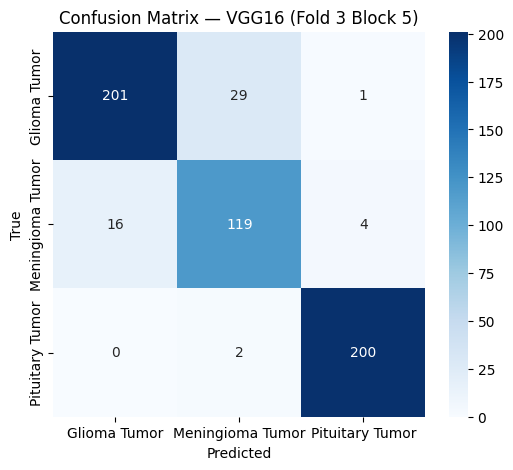

Fold: 3 block 4

Fold: 3 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0507 - accuracy: 0.9374 | val_loss: 0.0735 - val_accuracy: 0.9021
val_accuracy improved from 0.0000 to 0.9021, saving weights to /kaggle/working/VGG16_block_4_fold_3.pth


Epoch 2/50 | loss: 0.0466 - accuracy: 0.9494 | val_loss: 0.0750 - val_accuracy: 0.8969
val_accuracy did not improve from 0.9021


Epoch 3/50 | loss: 0.0390 - accuracy: 0.9494 | val_loss: 0.0722 - val_accuracy: 0.9056
val_accuracy improved from 0.9021 to 0.9056, saving weights to /kaggle/working/VGG16_block_4_fold_3.pth


Epoch 4/50 | loss: 0.0308 - accuracy: 0.9591 | val_loss: 0.0751 - val_accuracy: 0.9038
val_accuracy did not improve from 0.9056


...

Epoch 16/50 | loss: 0.0121 - accuracy: 0.9864 | val_loss: 0.0694 - val_accuracy: 0.9108
val_accuracy did not improve from 0.9196


Epoch 17/50 | loss: 0.0117 - accuracy: 0.9852 | val_loss: 0.0693 - val_accuracy: 0.9091
val_accuracy did not improve from 0.9196


Epoch 18/50 | loss: 0.0109 - accuracy: 0.9856 | val_loss: 0.0697 - val_accuracy: 0.9108
val_accuracy did not improve from 0.9196


Epoch 19/50 | loss: 0.0112 - accuracy: 0.9872 | val_loss: 0.0687 - val_accuracy: 0.9108
val_accuracy did not improve from 0.9196


Epoch 20/50 | loss: 0.0121 - accuracy: 0.9856 | val_loss: 0.0713 - val_accuracy: 0.9091
val_accuracy did not improve from 0.9196
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.069377   0.91958
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.92      0.91       231
Meningioma Tumor       0.84      0.82      0.83       139
 Pituitary Tumor       0.99      0.99      0.99       202

        accuracy                           0.92       572
       macro avg       0.91      0.91      0.91       572
    weighted avg       0.92      0.92      0.92       572



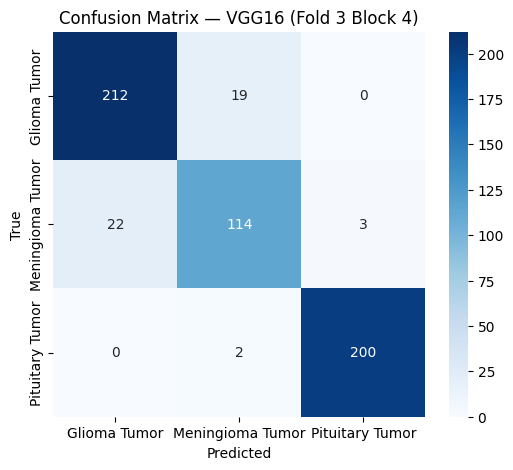

Fold: 3 block 3

Fold: 3 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0189 - accuracy: 0.9763 | val_loss: 0.0868 - val_accuracy: 0.9003
val_accuracy improved from 0.0000 to 0.9003, saving weights to /kaggle/working/VGG16_block_3_fold_3.pth


Epoch 2/50 | loss: 0.0138 - accuracy: 0.9839 | val_loss: 0.0687 - val_accuracy: 0.9161
val_accuracy improved from 0.9003 to 0.9161, saving weights to /kaggle/working/VGG16_block_3_fold_3.pth


Epoch 3/50 | loss: 0.0145 - accuracy: 0.9835 | val_loss: 0.0607 - val_accuracy: 0.9318
val_accuracy improved from 0.9161 to 0.9318, saving weights to /kaggle/working/VGG16_block_3_fold_3.pth


Epoch 4/50 | loss: 0.0137 - accuracy: 0.9827 | val_loss: 0.1030 - val_accuracy: 0.9021
val_accuracy did not improve from 0.9318


Epoch 5/50 | loss: 0.0116 - accuracy: 0.9835 | val_loss: 0.0656 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9318


Epoch 6/50 | loss: 0.0098 - accuracy: 0.9868 | val_loss: 0.0786 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9318


Epoch 7/50 | loss: 0.0165 - accuracy: 0.9783 | val_loss: 0.0607 - val_accuracy: 0.9301
val_accuracy did not improve from 0.9318


Epoch 8/50 | loss: 0.0083 - accuracy: 0.9900 | val_loss: 0.0612 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9318


Epoch 9/50 | loss: 0.0076 - accuracy: 0.9908 | val_loss: 0.0661 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9318
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.060657  0.931818
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.94      0.93       231
Meningioma Tumor       0.87      0.84      0.86       139
 Pituitary Tumor       0.99      0.99      0.99       202

        accuracy                           0.93       572
       macro avg       0.93      0.92      0.92       572
    weighted avg       0.93      0.93      0.93       572



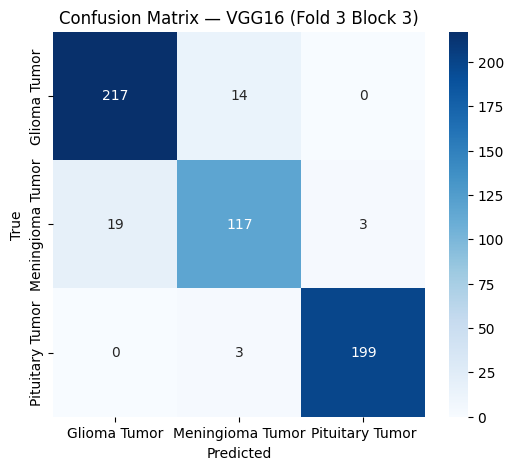

Fold: 3 block 2

Fold: 3 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0121 - accuracy: 0.9856 | val_loss: 0.0955 - val_accuracy: 0.9056
val_accuracy improved from 0.0000 to 0.9056, saving weights to /kaggle/working/VGG16_block_2_fold_3.pth


Epoch 2/50 | loss: 0.0107 - accuracy: 0.9880 | val_loss: 0.0671 - val_accuracy: 0.9266
val_accuracy improved from 0.9056 to 0.9266, saving weights to /kaggle/working/VGG16_block_2_fold_3.pth


Epoch 3/50 | loss: 0.0141 - accuracy: 0.9843 | val_loss: 0.0933 - val_accuracy: 0.9178
val_accuracy did not improve from 0.9266


Epoch 4/50 | loss: 0.0133 - accuracy: 0.9835 | val_loss: 0.0959 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9266


Epoch 5/50 | loss: 0.0144 - accuracy: 0.9811 | val_loss: 0.1007 - val_accuracy: 0.9038
val_accuracy did not improve from 0.9266


Epoch 6/50 | loss: 0.0121 - accuracy: 0.9880 | val_loss: 0.0939 - val_accuracy: 0.9126
val_accuracy did not improve from 0.9266


Epoch 7/50 | loss: 0.0065 - accuracy: 0.9920 | val_loss: 0.0744 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9266


Epoch 8/50 | loss: 0.0060 - accuracy: 0.9928 | val_loss: 0.0735 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9266
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.067081  0.926573
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.90      0.91       231
Meningioma Tumor       0.82      0.89      0.86       139
 Pituitary Tumor       1.00      0.99      0.99       202

        accuracy                           0.93       572
       macro avg       0.92      0.92      0.92       572
    weighted avg       0.93      0.93      0.93       572



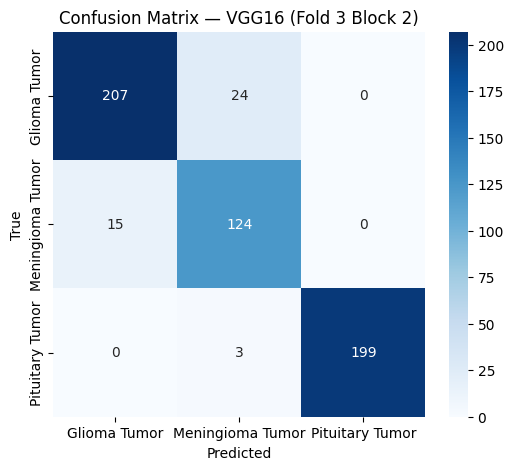

Fold: 3 block 1

Fold: 3 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0171 - accuracy: 0.9823 | val_loss: 0.0626 - val_accuracy: 0.9353
val_accuracy improved from 0.0000 to 0.9353, saving weights to /kaggle/working/VGG16_block_1_fold_3.pth


Epoch 2/50 | loss: 0.0097 - accuracy: 0.9904 | val_loss: 0.0854 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9353


Epoch 3/50 | loss: 0.0090 - accuracy: 0.9880 | val_loss: 0.0770 - val_accuracy: 0.9266
val_accuracy did not improve from 0.9353


Epoch 4/50 | loss: 0.0085 - accuracy: 0.9876 | val_loss: 0.0795 - val_accuracy: 0.9301
val_accuracy did not improve from 0.9353


...

Epoch 7/50 | loss: 0.0077 - accuracy: 0.9888 | val_loss: 0.0689 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9388


Epoch 8/50 | loss: 0.0086 - accuracy: 0.9884 | val_loss: 0.0656 - val_accuracy: 0.9318
val_accuracy did not improve from 0.9388


Epoch 9/50 | loss: 0.0055 - accuracy: 0.9924 | val_loss: 0.0801 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9388


Epoch 10/50 | loss: 0.0036 - accuracy: 0.9956 | val_loss: 0.0748 - val_accuracy: 0.9266
val_accuracy did not improve from 0.9388


Epoch 11/50 | loss: 0.0039 - accuracy: 0.9960 | val_loss: 0.0731 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9388
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.056569  0.938811
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.93      0.93       231
Meningioma Tumor       0.86      0.90      0.88       139
 Pituitary Tumor       1.00      0.98      0.99       202

        accuracy                           0.94       572
       macro avg       0.93      0.94      0.93       572
    weighted avg       0.94      0.94      0.94       572



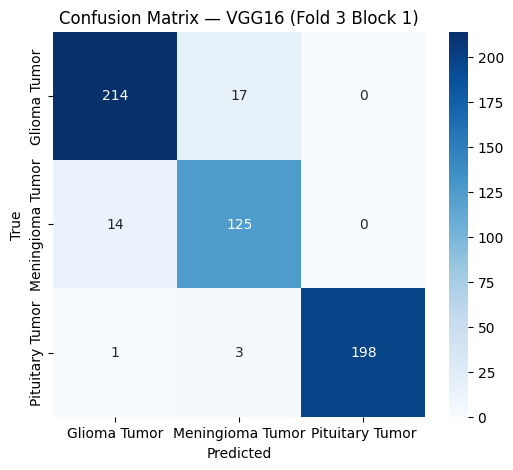

Fold: 4 block 6

Fold: 4 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.4785 - accuracy: 0.4335 | val_loss: 0.4485 - val_accuracy: 0.5223
val_accuracy improved from 0.0000 to 0.5223, saving weights to /kaggle/working/VGG16_block_6_fold_4.pth


Epoch 2/50 | loss: 0.4400 - accuracy: 0.5209 | val_loss: 0.4000 - val_accuracy: 0.6306
val_accuracy improved from 0.5223 to 0.6306, saving weights to /kaggle/working/VGG16_block_6_fold_4.pth


Epoch 3/50 | loss: 0.4091 - accuracy: 0.5788 | val_loss: 0.3690 - val_accuracy: 0.7468
val_accuracy improved from 0.6306 to 0.7468, saving weights to /kaggle/working/VGG16_block_6_fold_4.pth


Epoch 4/50 | loss: 0.3813 - accuracy: 0.6355 | val_loss: 0.3392 - val_accuracy: 0.7771
val_accuracy improved from 0.7468 to 0.7771, saving weights to /kaggle/working/VGG16_block_6_fold_4.pth


...

Epoch 29/50 | loss: 0.2107 - accuracy: 0.7927 | val_loss: 0.1557 - val_accuracy: 0.8615
val_accuracy did not improve from 0.8631


Epoch 30/50 | loss: 0.2088 - accuracy: 0.7886 | val_loss: 0.1556 - val_accuracy: 0.8567
val_accuracy did not improve from 0.8631


Epoch 31/50 | loss: 0.2025 - accuracy: 0.7968 | val_loss: 0.1543 - val_accuracy: 0.8567
val_accuracy did not improve from 0.8631


Epoch 32/50 | loss: 0.2038 - accuracy: 0.7947 | val_loss: 0.1519 - val_accuracy: 0.8583
val_accuracy did not improve from 0.8631


Epoch 33/50 | loss: 0.2041 - accuracy: 0.7976 | val_loss: 0.1498 - val_accuracy: 0.8599
val_accuracy did not improve from 0.8631
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.159142  0.863057
                  precision    recall  f1-score   support

    Glioma Tumor       0.83      0.99      0.90       325
Meningioma Tumor       0.82      0.48      0.60       124
 Pituitary Tumor       0.96      0.91      0.93       179

        accuracy                           0.86       628
       macro avg       0.87      0.79      0.81       628
    weighted avg       0.86      0.86      0.85       628



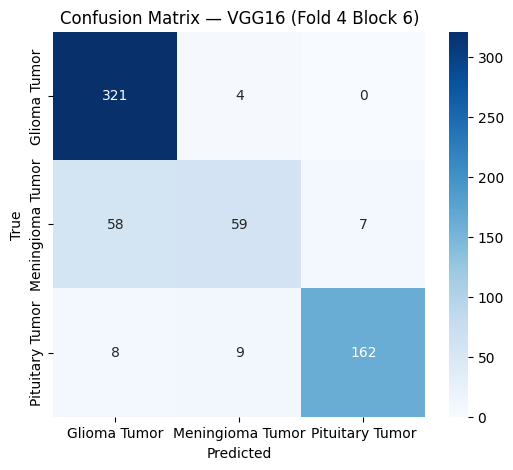

Fold: 4 block 5

Fold: 4 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.1748 - accuracy: 0.8198 | val_loss: 0.1178 - val_accuracy: 0.8583
val_accuracy improved from 0.0000 to 0.8583, saving weights to /kaggle/working/VGG16_block_5_fold_4.pth


Epoch 2/50 | loss: 0.1495 - accuracy: 0.8222 | val_loss: 0.1179 - val_accuracy: 0.8646
val_accuracy improved from 0.8583 to 0.8646, saving weights to /kaggle/working/VGG16_block_5_fold_4.pth


Epoch 3/50 | loss: 0.1310 - accuracy: 0.8526 | val_loss: 0.0932 - val_accuracy: 0.8933
val_accuracy improved from 0.8646 to 0.8933, saving weights to /kaggle/working/VGG16_block_5_fold_4.pth


Epoch 4/50 | loss: 0.1177 - accuracy: 0.8633 | val_loss: 0.0801 - val_accuracy: 0.9188
val_accuracy improved from 0.8933 to 0.9188, saving weights to /kaggle/working/VGG16_block_5_fold_4.pth


...

Epoch 24/50 | loss: 0.0592 - accuracy: 0.9253 | val_loss: 0.0576 - val_accuracy: 0.9443
val_accuracy did not improve from 0.9490


Epoch 25/50 | loss: 0.0640 - accuracy: 0.9261 | val_loss: 0.0576 - val_accuracy: 0.9490
val_accuracy did not improve from 0.9490


Epoch 26/50 | loss: 0.0578 - accuracy: 0.9294 | val_loss: 0.0577 - val_accuracy: 0.9490
val_accuracy did not improve from 0.9490


Epoch 27/50 | loss: 0.0571 - accuracy: 0.9265 | val_loss: 0.0579 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9490


Epoch 28/50 | loss: 0.0544 - accuracy: 0.9294 | val_loss: 0.0579 - val_accuracy: 0.9459
val_accuracy did not improve from 0.9490
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.056162  0.949045
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       325
Meningioma Tumor       0.88      0.87      0.87       124
 Pituitary Tumor       0.98      0.94      0.96       179

        accuracy                           0.95       628
       macro avg       0.94      0.93      0.93       628
    weighted avg       0.95      0.95      0.95       628



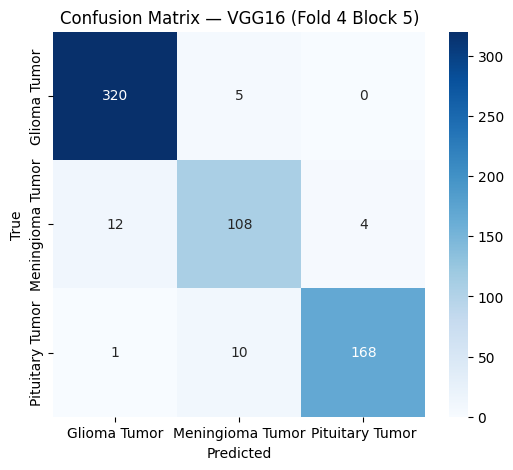

Fold: 4 block 4

Fold: 4 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0572 - accuracy: 0.9331 | val_loss: 0.0513 - val_accuracy: 0.9459
val_accuracy improved from 0.0000 to 0.9459, saving weights to /kaggle/working/VGG16_block_4_fold_4.pth


Epoch 2/50 | loss: 0.0577 - accuracy: 0.9319 | val_loss: 0.0557 - val_accuracy: 0.9506
val_accuracy improved from 0.9459 to 0.9506, saving weights to /kaggle/working/VGG16_block_4_fold_4.pth


Epoch 3/50 | loss: 0.0494 - accuracy: 0.9372 | val_loss: 0.0558 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9506


Epoch 4/50 | loss: 0.0469 - accuracy: 0.9405 | val_loss: 0.0500 - val_accuracy: 0.9506
val_accuracy did not improve from 0.9506


...

Epoch 12/50 | loss: 0.0209 - accuracy: 0.9713 | val_loss: 0.0452 - val_accuracy: 0.9618
val_accuracy did not improve from 0.9650


Epoch 13/50 | loss: 0.0233 - accuracy: 0.9754 | val_loss: 0.0473 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9650


Epoch 14/50 | loss: 0.0192 - accuracy: 0.9766 | val_loss: 0.0490 - val_accuracy: 0.9634
val_accuracy did not improve from 0.9650


Epoch 15/50 | loss: 0.0170 - accuracy: 0.9774 | val_loss: 0.0486 - val_accuracy: 0.9634
val_accuracy did not improve from 0.9650


Epoch 16/50 | loss: 0.0157 - accuracy: 0.9819 | val_loss: 0.0483 - val_accuracy: 0.9634
val_accuracy did not improve from 0.9650
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.043983  0.964968
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      1.00      0.98       325
Meningioma Tumor       0.93      0.91      0.92       124
 Pituitary Tumor       0.98      0.94      0.96       179

        accuracy                           0.96       628
       macro avg       0.96      0.95      0.95       628
    weighted avg       0.96      0.96      0.96       628



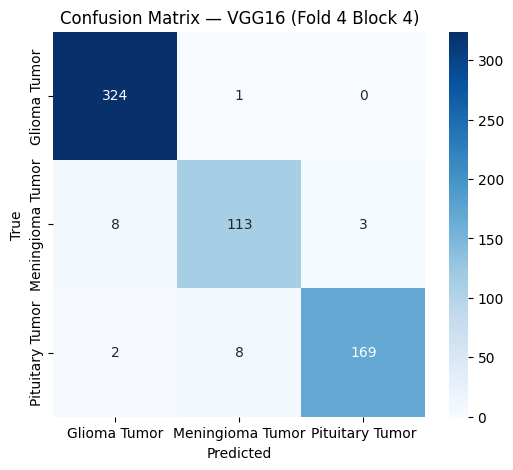

Fold: 4 block 3

Fold: 4 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0242 - accuracy: 0.9696 | val_loss: 0.0426 - val_accuracy: 0.9650
val_accuracy improved from 0.0000 to 0.9650, saving weights to /kaggle/working/VGG16_block_3_fold_4.pth


Epoch 2/50 | loss: 0.0241 - accuracy: 0.9692 | val_loss: 0.0453 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9650


Epoch 3/50 | loss: 0.0218 - accuracy: 0.9741 | val_loss: 0.0519 - val_accuracy: 0.9522
val_accuracy did not improve from 0.9650


Epoch 4/50 | loss: 0.0180 - accuracy: 0.9791 | val_loss: 0.0534 - val_accuracy: 0.9522
val_accuracy did not improve from 0.9650


Epoch 5/50 | loss: 0.0202 - accuracy: 0.9729 | val_loss: 0.0515 - val_accuracy: 0.9506
val_accuracy did not improve from 0.9650


Epoch 6/50 | loss: 0.0138 - accuracy: 0.9852 | val_loss: 0.0489 - val_accuracy: 0.9522
val_accuracy did not improve from 0.9650


Epoch 7/50 | loss: 0.0127 - accuracy: 0.9823 | val_loss: 0.0489 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9650
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.042623  0.964968
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.99      0.98       325
Meningioma Tumor       0.93      0.91      0.92       124
 Pituitary Tumor       0.98      0.95      0.96       179

        accuracy                           0.96       628
       macro avg       0.96      0.95      0.96       628
    weighted avg       0.96      0.96      0.96       628



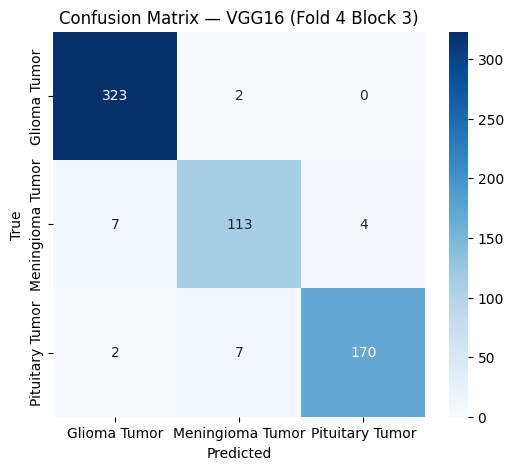

Fold: 4 block 2

Fold: 4 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0277 - accuracy: 0.9704 | val_loss: 0.0429 - val_accuracy: 0.9554
val_accuracy improved from 0.0000 to 0.9554, saving weights to /kaggle/working/VGG16_block_2_fold_4.pth


Epoch 2/50 | loss: 0.0264 - accuracy: 0.9618 | val_loss: 0.0455 - val_accuracy: 0.9618
val_accuracy improved from 0.9554 to 0.9618, saving weights to /kaggle/working/VGG16_block_2_fold_4.pth


Epoch 3/50 | loss: 0.0194 - accuracy: 0.9737 | val_loss: 0.0516 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9618


Epoch 4/50 | loss: 0.0143 - accuracy: 0.9803 | val_loss: 0.0562 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9618


Epoch 5/50 | loss: 0.0187 - accuracy: 0.9774 | val_loss: 0.0687 - val_accuracy: 0.9506
val_accuracy did not improve from 0.9618


Epoch 6/50 | loss: 0.0124 - accuracy: 0.9819 | val_loss: 0.0520 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9618


Epoch 7/50 | loss: 0.0136 - accuracy: 0.9828 | val_loss: 0.0529 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9618


Epoch 8/50 | loss: 0.0093 - accuracy: 0.9910 | val_loss: 0.0522 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9618
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.045543  0.961783
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       325
Meningioma Tumor       0.89      0.94      0.91       124
 Pituitary Tumor       0.98      0.94      0.96       179

        accuracy                           0.96       628
       macro avg       0.95      0.95      0.95       628
    weighted avg       0.96      0.96      0.96       628



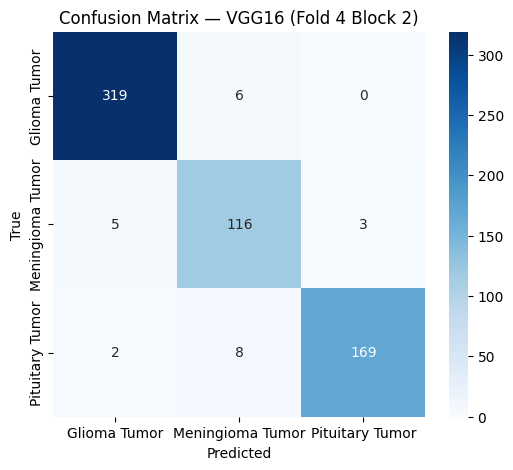

Fold: 4 block 1

Fold: 4 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0210 - accuracy: 0.9733 | val_loss: 0.0797 - val_accuracy: 0.9299
val_accuracy improved from 0.0000 to 0.9299, saving weights to /kaggle/working/VGG16_block_1_fold_4.pth


Epoch 2/50 | loss: 0.0192 - accuracy: 0.9750 | val_loss: 0.0609 - val_accuracy: 0.9602
val_accuracy improved from 0.9299 to 0.9602, saving weights to /kaggle/working/VGG16_block_1_fold_4.pth


Epoch 3/50 | loss: 0.0158 - accuracy: 0.9799 | val_loss: 0.0513 - val_accuracy: 0.9618
val_accuracy improved from 0.9602 to 0.9618, saving weights to /kaggle/working/VGG16_block_1_fold_4.pth


Epoch 4/50 | loss: 0.0171 - accuracy: 0.9791 | val_loss: 0.0527 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9618


Epoch 5/50 | loss: 0.0127 - accuracy: 0.9856 | val_loss: 0.0734 - val_accuracy: 0.9506
val_accuracy did not improve from 0.9618


Epoch 6/50 | loss: 0.0134 - accuracy: 0.9836 | val_loss: 0.0645 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9618


Epoch 7/50 | loss: 0.0145 - accuracy: 0.9811 | val_loss: 0.0665 - val_accuracy: 0.9522
val_accuracy did not improve from 0.9618


Epoch 8/50 | loss: 0.0089 - accuracy: 0.9889 | val_loss: 0.0605 - val_accuracy: 0.9554
val_accuracy did not improve from 0.9618


Epoch 9/50 | loss: 0.0060 - accuracy: 0.9922 | val_loss: 0.0592 - val_accuracy: 0.9554
val_accuracy did not improve from 0.9618
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.051312  0.961783
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.98      0.98       325
Meningioma Tumor       0.88      0.94      0.91       124
 Pituitary Tumor       0.98      0.95      0.96       179

        accuracy                           0.96       628
       macro avg       0.95      0.96      0.95       628
    weighted avg       0.96      0.96      0.96       628



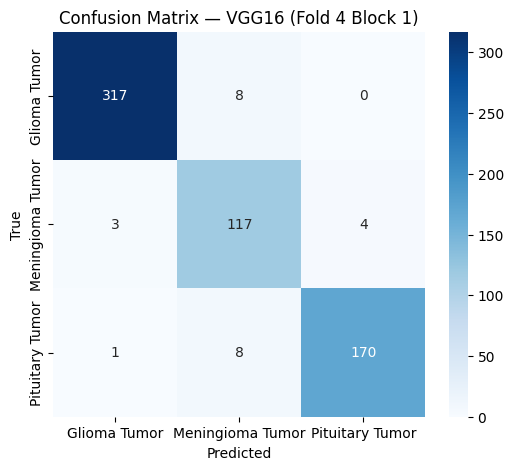

Fold: 5 block 6

Fold: 5 - Block 6
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      (14,714,688)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 1,539
Non-trainable params: 14,714,688
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.5120 - accuracy: 0.3569 | val_loss: 0.4418 - val_accuracy: 0.5941
val_accuracy improved from 0.0000 to 0.5941, saving weights to /kaggle/working/VGG16_block_6_fold_5.pth


Epoch 2/50 | loss: 0.4451 - accuracy: 0.5048 | val_loss: 0.4159 - val_accuracy: 0.6299
val_accuracy improved from 0.5941 to 0.6299, saving weights to /kaggle/working/VGG16_block_6_fold_5.pth


Epoch 3/50 | loss: 0.4102 - accuracy: 0.5630 | val_loss: 0.3941 - val_accuracy: 0.6610
val_accuracy improved from 0.6299 to 0.6610, saving weights to /kaggle/working/VGG16_block_6_fold_5.pth


Epoch 4/50 | loss: 0.3864 - accuracy: 0.6109 | val_loss: 0.3699 - val_accuracy: 0.6610
val_accuracy did not improve from 0.6610


...

Epoch 21/50 | loss: 0.2177 - accuracy: 0.7914 | val_loss: 0.2479 - val_accuracy: 0.7294
val_accuracy did not improve from 0.7325


Epoch 22/50 | loss: 0.2108 - accuracy: 0.8059 | val_loss: 0.2461 - val_accuracy: 0.7294
val_accuracy did not improve from 0.7325


Epoch 23/50 | loss: 0.2092 - accuracy: 0.8026 | val_loss: 0.2456 - val_accuracy: 0.7263
val_accuracy did not improve from 0.7325


Epoch 24/50 | loss: 0.2072 - accuracy: 0.7980 | val_loss: 0.2433 - val_accuracy: 0.7278
val_accuracy did not improve from 0.7325


Epoch 25/50 | loss: 0.2000 - accuracy: 0.8100 | val_loss: 0.2401 - val_accuracy: 0.7325
val_accuracy did not improve from 0.7325
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.252548  0.732504
                  precision    recall  f1-score   support

    Glioma Tumor       0.70      0.91      0.79       287
Meningioma Tumor       0.64      0.28      0.39       166
 Pituitary Tumor       0.83      0.86      0.84       190

        accuracy                           0.73       643
       macro avg       0.72      0.68      0.67       643
    weighted avg       0.72      0.73      0.70       643



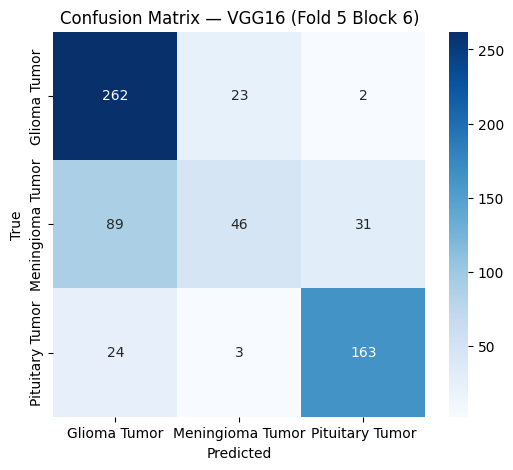

Fold: 5 block 5

Fold: 5 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 7,080,963
Non-trainable params: 7,635,264
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/back

Epoch 1/50 | loss: 0.1710 - accuracy: 0.8236 | val_loss: 0.2175 - val_accuracy: 0.7698
val_accuracy improved from 0.0000 to 0.7698, saving weights to /kaggle/working/VGG16_block_5_fold_5.pth


Epoch 2/50 | loss: 0.1289 - accuracy: 0.8583 | val_loss: 0.1969 - val_accuracy: 0.7807
val_accuracy improved from 0.7698 to 0.7807, saving weights to /kaggle/working/VGG16_block_5_fold_5.pth


Epoch 3/50 | loss: 0.1048 - accuracy: 0.8802 | val_loss: 0.1837 - val_accuracy: 0.8009
val_accuracy improved from 0.7807 to 0.8009, saving weights to /kaggle/working/VGG16_block_5_fold_5.pth


Epoch 4/50 | loss: 0.0950 - accuracy: 0.8864 | val_loss: 0.1951 - val_accuracy: 0.8009
val_accuracy did not improve from 0.8009


...

Epoch 14/50 | loss: 0.0552 - accuracy: 0.9285 | val_loss: 0.1927 - val_accuracy: 0.8476
val_accuracy did not improve from 0.8600


Epoch 15/50 | loss: 0.0568 - accuracy: 0.9318 | val_loss: 0.1929 - val_accuracy: 0.8538
val_accuracy did not improve from 0.8600


Epoch 16/50 | loss: 0.0533 - accuracy: 0.9339 | val_loss: 0.1922 - val_accuracy: 0.8491
val_accuracy did not improve from 0.8600


Epoch 17/50 | loss: 0.0549 - accuracy: 0.9302 | val_loss: 0.1907 - val_accuracy: 0.8523
val_accuracy did not improve from 0.8600


Epoch 18/50 | loss: 0.0525 - accuracy: 0.9413 | val_loss: 0.1907 - val_accuracy: 0.8523
val_accuracy did not improve from 0.8600
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.193522  0.860031
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.92      0.91       287
Meningioma Tumor       0.77      0.67      0.72       166
 Pituitary Tumor       0.87      0.93      0.90       190

        accuracy                           0.86       643
       macro avg       0.85      0.84      0.84       643
    weighted avg       0.86      0.86      0.86       643



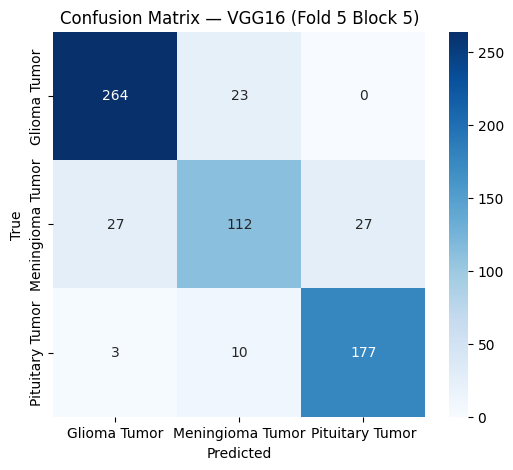

Fold: 5 block 4

Fold: 5 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 12,980,739
Non-trainable params: 1,735,488
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0593 - accuracy: 0.9298 | val_loss: 0.1977 - val_accuracy: 0.8414
val_accuracy improved from 0.0000 to 0.8414, saving weights to /kaggle/working/VGG16_block_4_fold_5.pth


Epoch 2/50 | loss: 0.0564 - accuracy: 0.9281 | val_loss: 0.1974 - val_accuracy: 0.8585
val_accuracy improved from 0.8414 to 0.8585, saving weights to /kaggle/working/VGG16_block_4_fold_5.pth


Epoch 3/50 | loss: 0.0447 - accuracy: 0.9401 | val_loss: 0.1900 - val_accuracy: 0.8694
val_accuracy improved from 0.8585 to 0.8694, saving weights to /kaggle/working/VGG16_block_4_fold_5.pth


Epoch 4/50 | loss: 0.0382 - accuracy: 0.9504 | val_loss: 0.2209 - val_accuracy: 0.8663
val_accuracy did not improve from 0.8694


...

Epoch 8/50 | loss: 0.0252 - accuracy: 0.9670 | val_loss: 0.2280 - val_accuracy: 0.8678
val_accuracy did not improve from 0.8802


Epoch 9/50 | loss: 0.0325 - accuracy: 0.9591 | val_loss: 0.1980 - val_accuracy: 0.8771
val_accuracy did not improve from 0.8802


Epoch 10/50 | loss: 0.0233 - accuracy: 0.9711 | val_loss: 0.2182 - val_accuracy: 0.8756
val_accuracy did not improve from 0.8802


Epoch 11/50 | loss: 0.0231 - accuracy: 0.9744 | val_loss: 0.2219 - val_accuracy: 0.8771
val_accuracy did not improve from 0.8802


Epoch 12/50 | loss: 0.0211 - accuracy: 0.9769 | val_loss: 0.2148 - val_accuracy: 0.8787
val_accuracy did not improve from 0.8802
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.211296  0.880249
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.95      0.93       287
Meningioma Tumor       0.86      0.66      0.75       166
 Pituitary Tumor       0.85      0.96      0.90       190

        accuracy                           0.88       643
       macro avg       0.87      0.86      0.86       643
    weighted avg       0.88      0.88      0.88       643



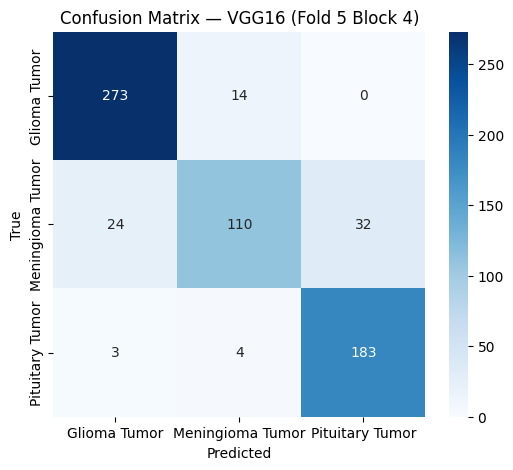

Fold: 5 block 3

Fold: 5 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,456,067
Non-trainable params: 260,160
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0381 - accuracy: 0.9554 | val_loss: 0.2010 - val_accuracy: 0.8787
val_accuracy improved from 0.0000 to 0.8787, saving weights to /kaggle/working/VGG16_block_3_fold_5.pth


Epoch 2/50 | loss: 0.0315 - accuracy: 0.9632 | val_loss: 0.2001 - val_accuracy: 0.8802
val_accuracy improved from 0.8787 to 0.8802, saving weights to /kaggle/working/VGG16_block_3_fold_5.pth


Epoch 3/50 | loss: 0.0295 - accuracy: 0.9641 | val_loss: 0.2014 - val_accuracy: 0.8647
val_accuracy did not improve from 0.8802


Epoch 4/50 | loss: 0.0278 - accuracy: 0.9727 | val_loss: 0.1780 - val_accuracy: 0.8896
val_accuracy improved from 0.8802 to 0.8896, saving weights to /kaggle/working/VGG16_block_3_fold_5.pth


...

Epoch 13/50 | loss: 0.0114 - accuracy: 0.9876 | val_loss: 0.2493 - val_accuracy: 0.8958
val_accuracy did not improve from 0.9036


Epoch 14/50 | loss: 0.0103 - accuracy: 0.9884 | val_loss: 0.2529 - val_accuracy: 0.8958
val_accuracy did not improve from 0.9036


Epoch 15/50 | loss: 0.0105 - accuracy: 0.9864 | val_loss: 0.2569 - val_accuracy: 0.9005
val_accuracy did not improve from 0.9036


Epoch 16/50 | loss: 0.0109 - accuracy: 0.9868 | val_loss: 0.2562 - val_accuracy: 0.8974
val_accuracy did not improve from 0.9036


Epoch 17/50 | loss: 0.0104 - accuracy: 0.9855 | val_loss: 0.2561 - val_accuracy: 0.8942
val_accuracy did not improve from 0.9036
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.237801  0.903577
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.93      0.94       287
Meningioma Tumor       0.84      0.79      0.81       166
 Pituitary Tumor       0.87      0.97      0.92       190

        accuracy                           0.90       643
       macro avg       0.89      0.89      0.89       643
    weighted avg       0.90      0.90      0.90       643



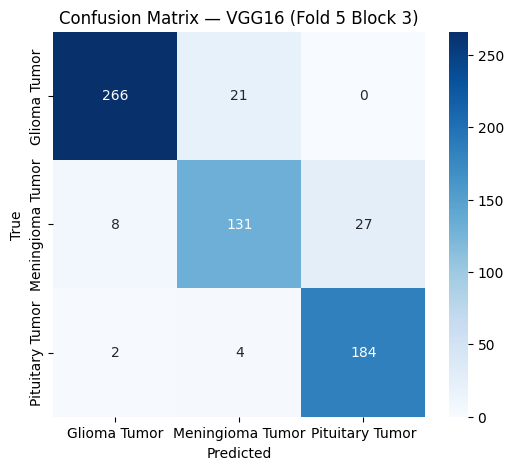

Fold: 5 block 2

Fold: 5 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,677,507
Non-trainable params: 38,720
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backwa

Epoch 1/50 | loss: 0.0204 - accuracy: 0.9732 | val_loss: 0.2329 - val_accuracy: 0.8678
val_accuracy improved from 0.0000 to 0.8678, saving weights to /kaggle/working/VGG16_block_2_fold_5.pth


Epoch 2/50 | loss: 0.0130 - accuracy: 0.9810 | val_loss: 0.2878 - val_accuracy: 0.8725
val_accuracy improved from 0.8678 to 0.8725, saving weights to /kaggle/working/VGG16_block_2_fold_5.pth


Epoch 3/50 | loss: 0.0113 - accuracy: 0.9847 | val_loss: 0.2440 - val_accuracy: 0.8927
val_accuracy improved from 0.8725 to 0.8927, saving weights to /kaggle/working/VGG16_block_2_fold_5.pth


Epoch 4/50 | loss: 0.0139 - accuracy: 0.9827 | val_loss: 0.2667 - val_accuracy: 0.9051
val_accuracy improved from 0.8927 to 0.9051, saving weights to /kaggle/working/VGG16_block_2_fold_5.pth


...

Epoch 6/50 | loss: 0.0079 - accuracy: 0.9922 | val_loss: 0.2752 - val_accuracy: 0.8989
val_accuracy did not improve from 0.9051


Epoch 7/50 | loss: 0.0071 - accuracy: 0.9909 | val_loss: 0.2785 - val_accuracy: 0.9005
val_accuracy did not improve from 0.9051


Epoch 8/50 | loss: 0.0081 - accuracy: 0.9888 | val_loss: 0.2592 - val_accuracy: 0.9036
val_accuracy did not improve from 0.9051


Epoch 9/50 | loss: 0.0070 - accuracy: 0.9917 | val_loss: 0.2718 - val_accuracy: 0.8942
val_accuracy did not improve from 0.9051


Epoch 10/50 | loss: 0.0054 - accuracy: 0.9938 | val_loss: 0.2653 - val_accuracy: 0.9036
val_accuracy did not improve from 0.9051
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.266676  0.905132
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.93      0.95       287
Meningioma Tumor       0.86      0.78      0.82       166
 Pituitary Tumor       0.85      0.97      0.91       190

        accuracy                           0.91       643
       macro avg       0.89      0.90      0.89       643
    weighted avg       0.91      0.91      0.90       643



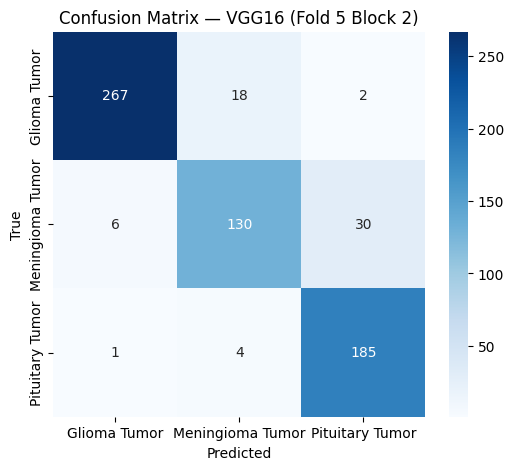

Fold: 5 block 1

Fold: 5 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
VGG16 (VGG16)                                 [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 512, 7, 7]      14,714,688           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 512, 7, 7]      [32, 512, 1, 1]      --                   --
├─Flatten (flatten)                           [32, 512, 1, 1]      [32, 512]            --                   --
├─Dropout (dropout)                           [32, 512]            [32, 512]            --                   --
├─Linear (classifier)                         [32, 512]            [32, 3]              1,539                True
Total params: 14,716,227
Trainable params: 14,716,227
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 491.53
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0114 - accuracy: 0.9851 | val_loss: 0.2128 - val_accuracy: 0.8974
val_accuracy improved from 0.0000 to 0.8974, saving weights to /kaggle/working/VGG16_block_1_fold_5.pth


Epoch 2/50 | loss: 0.0143 - accuracy: 0.9814 | val_loss: 0.2810 - val_accuracy: 0.8911
val_accuracy did not improve from 0.8974


Epoch 3/50 | loss: 0.0090 - accuracy: 0.9905 | val_loss: 0.2600 - val_accuracy: 0.9005
val_accuracy improved from 0.8974 to 0.9005, saving weights to /kaggle/working/VGG16_block_1_fold_5.pth


Epoch 4/50 | loss: 0.0114 - accuracy: 0.9855 | val_loss: 0.2993 - val_accuracy: 0.9020
val_accuracy improved from 0.9005 to 0.9020, saving weights to /kaggle/working/VGG16_block_1_fold_5.pth


...

Epoch 10/50 | loss: 0.0051 - accuracy: 0.9942 | val_loss: 0.2562 - val_accuracy: 0.9145
val_accuracy did not improve from 0.9160


Epoch 11/50 | loss: 0.0038 - accuracy: 0.9959 | val_loss: 0.2565 - val_accuracy: 0.9129
val_accuracy did not improve from 0.9160


Epoch 12/50 | loss: 0.0030 - accuracy: 0.9963 | val_loss: 0.2608 - val_accuracy: 0.9160
val_accuracy did not improve from 0.9160


Epoch 13/50 | loss: 0.0039 - accuracy: 0.9963 | val_loss: 0.2542 - val_accuracy: 0.9145
val_accuracy did not improve from 0.9160


Epoch 14/50 | loss: 0.0030 - accuracy: 0.9967 | val_loss: 0.2553 - val_accuracy: 0.9145
val_accuracy did not improve from 0.9160
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG16  0.246627  0.916019
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.93      0.96       287
Meningioma Tumor       0.85      0.83      0.84       166
 Pituitary Tumor       0.89      0.96      0.92       190

        accuracy                           0.92       643
       macro avg       0.90      0.91      0.91       643
    weighted avg       0.92      0.92      0.92       643



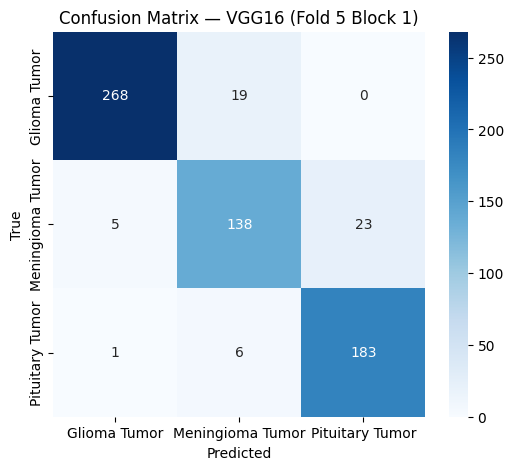

In [18]:
acc_b1, acc_b2, acc_b3, acc_b4, acc_b5, acc_b6 = [], [], [], [], [], []

for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_loader, val_loader = get_data_for_fold(k=fold_k)

    acc_b6.append(test_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k))

    torch.cuda.empty_cache()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block))

        torch.cuda.empty_cache()
        gc.collect()

    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]

for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 81.77%
Accuracy unfreeze block 5 - block 6: 91.19%
Accuracy unfreeze block 4 - block 6: 92.85%
Accuracy unfreeze block 3 - block 6: 93.59%
Accuracy unfreeze block 2 - block 6: 93.54%
Accuracy unfreeze block 1 - block 6: 94.30%
